# SPY net gamma exposure, 2023 to 2026: the sign of GEX and the next session

This notebook builds a daily history of SPY net gamma exposure (GEX) from Theta Data end-of-day option quotes and open interest, with gamma from the `engine_alo` American option engine. It then tests, by rule and without hand-picked dates, whether the sign of GEX at the close says anything about the next session: the size of the range, the size of the move, realized volatility over the following week, continuation against reversal, and whether gaps fade. Episodes of both regimes are selected by rule and charted. The result is reported either way.

## Sign convention and caveats

- GEX per contract = gamma x open interest x 100 x S x S x 0.01, in dollars per 1% move of SPY. Calls count positive, puts negative. This assumes dealers are long the calls and short the puts that customers hold. Dealer positioning is inferred, not observed.
- Open interest is published once a day at about 06:30 ET and reflects positions at the previous close. The GEX for day D uses the record available during D. Positions opened during D, including all 0DTE flow, are not in it.
- SPY only. SPX and ES options carry most of the index gamma and are not included.
- Gamma comes from a Black-Scholes-Merton American model with constant rate and dividend yield, at the implied vol that reproduces the closing mid. r is SOFR on the day, q is a flat 1.2% (SPY trailing yield, an assumption).
- "Model value" is what the engine outputs. "Mid" is the input.

## Data

Window: 2023-09-15 to 2026-09-14, the last completed session when the pull ran. Endpoints, one request per trading day with `expiration="*"` and `max_dte=120`: `option_history_eod` (quotes at the 17:15 ET report), `option_history_open_interest` (the 06:30 ET record), `option_history_greeks_eod` (vendor Greeks, used only in the cross-check). SPY daily bars from `stock_history_eod`, SOFR from `interest_rate_history_eod`. This account's rate history starts 2024-01-01, so the 2023 days use the first SOFR record (5.38%). The daily high and low are the narrower of the EOD report and the 1-minute session range, with the open and close folded in: the EOD bar for 2026-02-02 carries a low of 69.005, a decimal-shift print, and the intersection removes prints like it from either source. `gex_history/download.py` writes one parquet per endpoint per day under `gex_history/cache/`; this notebook never touches the network.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, "gex_history")
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
log = json.loads((G.RESULTS / "download_log.json").read_text())
print(f"window {log['window']['start']} to {log['window']['end']}: {log['trading_days_complete']} trading days with quotes, OI and Greeks")
print(f"holidays with no data: {len(log['holidays_no_data'])}; partial days: {len(log['partial_days'])}; cache {log['cache_mb']} MB")
print("rows per day:", {k: (v['min'], v['median'], v['max']) for k, v in log['rows_per_day'].items()})
stock, sofr, days = G.load_stock(verbose=True), G.load_sofr(), G.study_days()
print(f"{len(days)} study days {days[0]} to {days[-1]}; SPY bars from {stock.index.min():%Y-%m-%d}; SOFR {sofr.index.min():%Y-%m-%d} to {sofr.index.max():%Y-%m-%d}, last {sofr.iloc[-1]:.4f}")

window 2023-09-15 to 2026-09-14: 751 trading days with quotes, OI and Greeks
holidays with no data: 31; partial days: 0; cache 606.3 MB
rows per day: {'eod': (4034, 5740, 8958), 'oi': (4034, 5616, 8600), 'greeks': (4034, 5740, 8958)}
daily high/low: narrower of the EOD report and the 1-minute session range, open and close included, on 751 days; range narrowed by more than 0.1% of the close on 15 days: [('2023-10-03', 0.17), ('2023-11-10', 0.14), ('2023-11-21', 0.11), ('2023-12-04', 0.48), ('2023-12-15', 0.22), ('2023-12-18', 0.19), ('2024-02-13', 0.25), ('2024-03-07', 0.46), ('2024-04-23', 0.33), ('2024-08-21', 0.58), ('2024-10-01', 0.11), ('2025-03-14', 0.71), ('2025-04-16', 0.53), ('2025-12-22', 0.31), ('2026-02-02', 89.22)]
751 study days 2023-09-15 to 2026-09-14; SPY bars from 2023-06-01; SOFR 2024-01-01 to 2026-09-14, last 0.0362


## Chain prep

Per day D the universe is the OI record dated D. Quotes of D are joined on (expiration, strike, right). S is the SPY close on D, T = (expiration - D) / 365.25 years. Rules, in order:

- 1 <= days to expiry <= 120. Contracts expiring on D are gone at the close and drop out.
- 0.80 S <= strike <= 1.20 S. Gamma outside that band is negligible for GEX; the table after the next one shows the |GEX| share by band on one day solved without the cut.
- open interest > 0 (zero OI is zero GEX; those rows are not solved).
- bid > 0, ask >= bid, mid > intrinsic + 1e-6: the engine's own requirements. Contracts at or below intrinsic sit in the exercise region where the model gamma is 0, so they contribute 0 GEX by construction.

The scanner's `dte >= 7`, `mid >= 0.05` and `0.4 <= S/K <= 2.5` filters are not applied. They were for the IV benchmark, and near-dated, low-priced contracts are where SPY gamma lives. The table shows the share of the day's open interest in each bucket, median and max across days.

In [2]:
chain, shares = G.prep_all(days, stock, sofr)
ft = G.filter_table(shares)
ft.style.format({"median OI share": "{:.1%}", "max OI share": "{:.1%}"})

chain prep: 751 days, 2,392,386 rows; rows/day min 1926 median 3076 max 4866; 10.8s; skipped (no SPY bar): []


,what,median OI share,max OI share
bucket,,,
dte_lt_1,expires on D (gone at the close),5.6%,36.9%
dte_gt_120,more than 120 days to expiry,0.0%,0.0%
outside_band,strike outside 0.80 S to 1.20 S,24.8%,39.5%
oi_zero,"open interest 0 (row count only, no GEX)",0.0%,0.0%
no_quote,open interest but no EOD quote row,0.0%,0.0%
bid_le_0,bid = 0,1.7%,10.8%
ask_lt_bid,ask below bid,0.0%,0.0%
mid_le_intrinsic,"mid at or below intrinsic (exercise region, gamma 0)",0.1%,9.5%
kept,"kept, sent to the engine",65.2%,83.2%


In [3]:
day = [d for d in days if d.weekday() == 2][-10]        # a Wednesday near the end of the window
bs = G.band_share_day(day, float(stock.loc[pd.Timestamp(day), "close"]), G.rate_for(sofr, day))
print(f"{day}: share of total |GEX| and of OI by strike band, all strikes solved")
bs.style.format({"abs GEX share": "{:.2%}", "OI share": "{:.1%}"})

2026-07-08: share of total |GEX| and of OI by strike band, all strikes solved


,abs GEX share,OI share,contracts
band,,,
< 0.80 S,0.82%,28.8%,662
0.80 to 0.90 S,3.59%,17.6%,825
0.90 to 1.10 S,94.97%,50.1%,3112
1.10 to 1.20 S,0.61%,2.7%,149
> 1.20 S,0.02%,0.7%,57


## Engine run

`gexlib.solve_chain` mirrors `engine_alo/run_chain.py`: `Tables(7, 7, 27)`, `make_core(m_iter=4)`, a bracketed-secant IV solve with 12 model evaluations per contract, then one `Engine.price` call for model value, delta and gamma at the solved IV. Reference build: CPU, fp64. `iv_status` 0 means solved with the model value at the solved IV within 1e-3 of the mid; other codes are excluded from GEX and their OI share is reported. The excluded contracts are deep in-the-money calls whose mid sits below the zero-vol model value under the flat r and q. They cluster in the two weeks before SPY's quarterly ex-dividend dates, which is dividend-capture positioning that a continuous-yield model cannot fit. The vendor's gamma for those contracts is also 0, so the choice does not affect the cross-check.

In [4]:
sol, timings = G.solve_chain(chain, target="cpu", dtype="fp64")
rep = G.solve_report(sol)
print(timings)
print({k: v for k, v in rep.items() if k != "iv_status_counts"})
print("iv_status counts:", rep["iv_status_counts"])

{'target': 'cpu', 'dtype': 'fp64', 'device': 'CPU, 48 numba threads', 'n_contracts': 2392386, 'evals': 12, 't_compile_s': 1.72, 't_iv_s': 10.702, 't_greeks_s': 1.269}
{'rows': 2392386, 'oi_share_status_ne_0': 0.004718177022090681, 'resid_median': 6.078859637881351e-12, 'resid_p99': 3.702343462919088e-08, 'resid_max': 0.0004602282806160929, 'gamma_zero_rows': 39880}
iv_status counts: {0: 2352505, 1: 39881}


In [5]:
from numba import cuda
try:
    if cuda.is_available():
        if len(cuda.gpus) > 1:
            cuda.select_device(1)          # on this box index 1 is the NVIDIA RTX PRO 6000 Blackwell (96GB)
        sol32, t32 = G.solve_chain(chain, target="cuda", dtype="fp32")
        d_net = (sol32[sol32.iv_status == 0].groupby("date")["gex"].sum() - sol[sol.iv_status == 0].groupby("date")["gex"].sum()).abs()
        print(t32)
        print(f"GPU fp32 vs CPU fp64 daily net GEX: max abs diff {d_net.max():,.0f} USD, "
              f"max relative {(d_net / sol[sol.iv_status == 0].groupby('date')['gex'].sum().abs()).max():.2e}; timings for scale only")
    else:
        print("no CUDA device: GPU timing skipped")
except Exception as e:
    print(f"GPU pass skipped: {type(e).__name__}: {str(e)[:120]}")
print("all GEX numbers below come from the CPU fp64 run")

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/.venv/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


{'target': 'cuda', 'dtype': 'fp32', 'device': 'NVIDIA RTX PRO 6000 Blackwell Workstation Edition', 'n_contracts': 2392386, 'evals': 12, 't_compile_s': 2.09, 't_iv_s': 0.207, 't_greeks_s': 0.046}
GPU fp32 vs CPU fp64 daily net GEX: max abs diff 1,727,149 USD, max relative 2.76e-03; timings for scale only
all GEX numbers below come from the CPU fp64 run


### Daily series

`flip_level`: the chain is re-evaluated on a spot grid from 0.93 S to 1.07 S in 0.25% steps with each contract's IV held fixed, signed GEX is summed per grid point, and the zero crossing nearest to S is taken. NaN when the profile does not change sign on the grid. `wall_pos_strike` and `wall_neg_strike`: the strike with the largest positive and most negative net GEX summed over expirations. `regime` is the sign of `gex_net_usd`.

In [6]:
import time; t0 = time.perf_counter()
flips = G.flip_levels(sol, verbose=False)
print(f"flip grid: {len(flips)} days x 57 spot points, {time.perf_counter() - t0:.0f}s on the CPU; crossings per day {flips.n_crossings.value_counts().to_dict()}")
daily = G.daily_gex(sol, stock, flips)
daily.to_csv(G.RESULTS / "spy_gex_daily.csv", float_format="%.8g")
print(f"{len(daily)} days; negative net GEX on {(daily.regime < 0).mean():.1%} of days; "
      f"flip level on the grid on {daily.flip_level.notna().mean():.1%} of days; "
      f"median net GEX {daily.gex_net_usd.median() / 1e9:+.2f} $bn per 1%; "
      f"median share of |GEX| within 30 days to expiry {daily.gex_le30d_share.median():.1%}")
daily.head(8)

flip grid: 751 days x 57 spot points, 74s on the CPU; crossings per day {1: 747, 0: 4}


751 days; negative net GEX on 57.9% of days; flip level on the grid on 99.5% of days; median net GEX -1.22 $bn per 1%; median share of |GEX| within 30 days to expiry 71.1%


,S,open,high,low,close,ret_cc,range_pct,gex_net_usd,gex_call_usd,gex_put_usd,gex_le30d_share,n_contracts,oi_total,oi_solved_share,flip_level,wall_pos_strike,wall_neg_strike,regime
date,,,,,,,,,,,,,,,,,,
2023-09-15,443.37,447.09,447.480,442.92,443.37,-0.015643,0.010125,-1.089328e+10,7.292268e+09,-1.818555e+10,0.489091,1941,10338219,1.000000,452.010185,455.0,440.0,-1
2023-09-18,443.63,443.00,444.970,442.56,443.63,0.000586,0.005436,-8.697367e+09,9.513171e+09,-1.821054e+10,0.510718,1926,10773009,1.000000,450.425259,455.0,440.0,-1
2023-09-19,442.71,442.71,443.290,439.94,442.71,-0.002076,0.007551,-1.005307e+10,9.153485e+09,-1.920656e+10,0.504445,1990,10985330,1.000000,450.286890,455.0,440.0,-1
2023-09-20,438.64,444.02,444.435,438.43,438.64,-0.009236,0.013564,-1.234674e+10,8.409963e+09,-2.075670e+10,0.742640,2200,11172373,0.999956,448.953945,455.0,440.0,-1
2023-09-21,431.39,435.71,435.970,431.23,431.39,-0.016666,0.010806,-1.571842e+10,6.017245e+09,-2.173566e+10,0.681506,2371,12341244,0.999983,449.552185,455.0,430.0,-1
2023-09-22,430.42,432.49,434.100,429.99,430.42,-0.002251,0.009527,-1.191182e+10,6.775018e+09,-1.868684e+10,0.644942,2109,11319038,1.000000,444.692466,450.0,430.0,-1
2023-09-25,432.23,429.18,432.270,428.72,432.23,0.004196,0.008248,-1.213240e+10,8.293097e+09,-2.042550e+10,0.670837,2112,11896276,1.000000,445.747925,450.0,430.0,-1
2023-09-26,425.88,429.06,429.820,425.02,425.88,-0.014800,0.011105,-1.450712e+10,6.073393e+09,-2.058051e+10,0.657343,2121,11658866,1.000000,441.276473,450.0,430.0,-1


In [7]:
cols = ["S", "ret_cc", "range_pct", "gex_net_usd", "gex_call_usd", "gex_put_usd", "flip_level", "wall_pos_strike", "wall_neg_strike"]
fmt = {"gex_net_usd": "{:,.3e}", "gex_call_usd": "{:,.3e}", "gex_put_usd": "{:,.3e}", "ret_cc": "{:+.2%}", "range_pct": "{:.2%}", "flip_level": "{:.1f}"}
print("five most negative days"); display(daily.nsmallest(5, "gex_net_usd")[cols].style.format(fmt))
print("five most positive days"); display(daily.nlargest(5, "gex_net_usd")[cols].style.format(fmt))

five most negative days


,S,ret_cc,range_pct,gex_net_usd,gex_call_usd,gex_put_usd,flip_level,wall_pos_strike,wall_neg_strike
date,,,,,,,,,
2026-03-19 00:00:00,659.800000,-0.25%,1.18%,-1.933e+10,8.152e+09,-2.748e+10,678.6,700.000000,660.000000
2026-03-18 00:00:00,661.430000,-1.41%,1.27%,-1.709e+10,7.209e+09,-2.429e+10,680.7,700.000000,660.000000
2026-07-29 00:00:00,729.460000,-1.55%,1.83%,-1.660e+10,7.962e+09,-2.456e+10,750.9,760.000000,720.000000
2026-03-30 00:00:00,631.970000,-0.33%,1.75%,-1.620e+10,4.693e+09,-2.089e+10,673.5,700.000000,630.000000
2025-03-18 00:00:00,561.020000,-1.09%,1.05%,-1.616e+10,7.730e+09,-2.389e+10,587.4,610.000000,550.000000


five most positive days


,S,ret_cc,range_pct,gex_net_usd,gex_call_usd,gex_put_usd,flip_level,wall_pos_strike,wall_neg_strike
date,,,,,,,,,
2026-08-13 00:00:00,777.880000,+0.70%,0.68%,1.949e+10,3.308e+10,-1.359e+10,769.1,780.000000,765.000000
2025-12-24 00:00:00,690.380000,+0.35%,0.44%,1.277e+10,2.673e+10,-1.395e+10,686.5,690.000000,680.000000
2023-12-13 00:00:00,470.500000,+1.37%,1.43%,1.245e+10,2.097e+10,-8.514e+09,461.4,470.000000,450.000000
2024-09-19 00:00:00,570.980000,+1.69%,0.86%,1.172e+10,2.189e+10,-1.017e+10,566.8,570.000000,540.000000
2025-12-23 00:00:00,687.960000,+0.46%,0.63%,1.107e+10,2.471e+10,-1.364e+10,684.0,690.000000,670.000000


## F1: the whole window

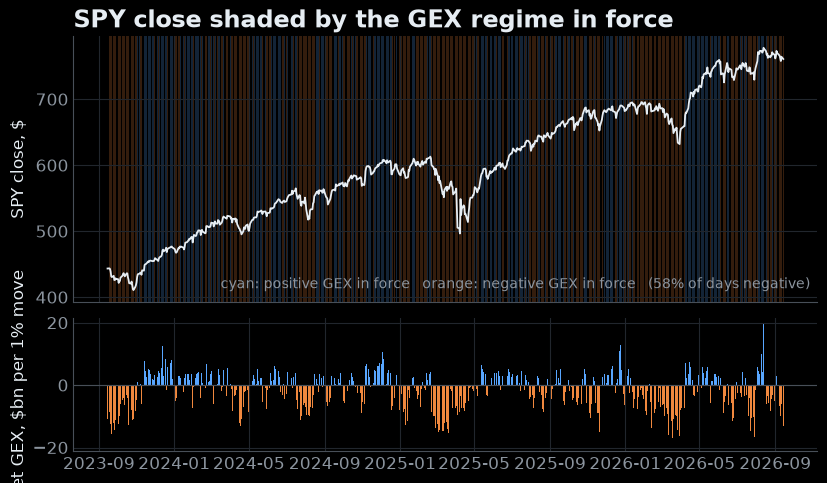

In [8]:
_ = G.fig_overview(daily, G.FIGURES / "f1_overview.png")

## Episodes, selected by rule

The regime on day D is the sign of GEX at the close of D and is in force for D+1. An episode is a run of at least 3 consecutive same-sign days. Negative episodes: the 4 most recent runs. Positive episodes: the 4 most recent runs of at least 10 days whose median GEX is in the top tercile of the whole history. For each: the SPY move while the regime was in force (close of the first day to the close of the day after the last), mean daily range and annualized realized vol inside the episode against the 20 days before it.

In [9]:
eps, info = G.select_episodes(daily, stock)
G.save_json({"rule": {"negative": "4 most recent runs of >= 3 days", "positive": "4 most recent runs of >= 10 days with median GEX in the top tercile"},
             "info": info, "episodes": eps.to_dict("records")}, G.RESULTS / "episodes.json")
print(info)
efmt = {"median_gex": "{:,.3e}", "spy_return_in_force": "{:+.2%}", "range_inside": "{:.2%}", "range_before": "{:.2%}", "rvol_inside": "{:.1%}", "rvol_before": "{:.1%}"}
eps.style.format(efmt)

{'n_runs': 155, 'top_tercile_gex_usd': 1270867579.17929, 'n_neg_runs_ge_min': 39, 'n_pos_runs_ge_min': 6, 'n_pos_runs_ge_min_top_tercile': 4, 'longest_pos_run': 20, 'longest_neg_run': 49}


,kind,sign,start,end,length,median_gex,spy_return_in_force,range_inside,range_before,rvol_inside,rvol_before,n_inside,n_before
0,neg,-1,2026-07-16 00:00:00,2026-07-31 00:00:00,12,-1.012e+10,+0.93%,1.07%,1.07%,15.8%,12.3%,12,20
1,neg,-1,2026-08-18 00:00:00,2026-08-26 00:00:00,7,-6.111e+09,+0.48%,0.55%,0.88%,8.0%,13.6%,7,20
2,neg,-1,2026-08-28 00:00:00,2026-09-02 00:00:00,4,-5.009e+09,+0.50%,0.64%,0.67%,12.2%,10.4%,4,20
3,neg,-1,2026-09-04 00:00:00,2026-09-14 00:00:00,6,-8.427e+09,-1.21%,0.52%,0.57%,9.7%,8.1%,5,20
4,pos,1,2024-06-05 00:00:00,2024-06-20 00:00:00,11,2.749e+09,+1.84%,0.71%,0.77%,6.3%,8.8%,11,20
5,pos,1,2024-11-19 00:00:00,2024-12-17 00:00:00,20,6.017e+09,-0.68%,0.72%,0.85%,12.8%,14.5%,20,20
6,pos,1,2025-11-25 00:00:00,2025-12-11 00:00:00,12,3.148e+09,+1.00%,0.76%,1.35%,8.1%,15.1%,12,20
7,pos,1,2026-08-03 00:00:00,2026-08-17 00:00:00,11,5.880e+09,+1.29%,0.67%,0.96%,11.1%,13.3%,11,20


## F2: one chart per episode

Candles shaded by the regime in force, the flip level dotted, the walls on the last episode day as ticks at the right edge, the daily range below. The dashed box marks the days on which the sign was observed; the shading is shifted by one day because the regime acts on the next session.

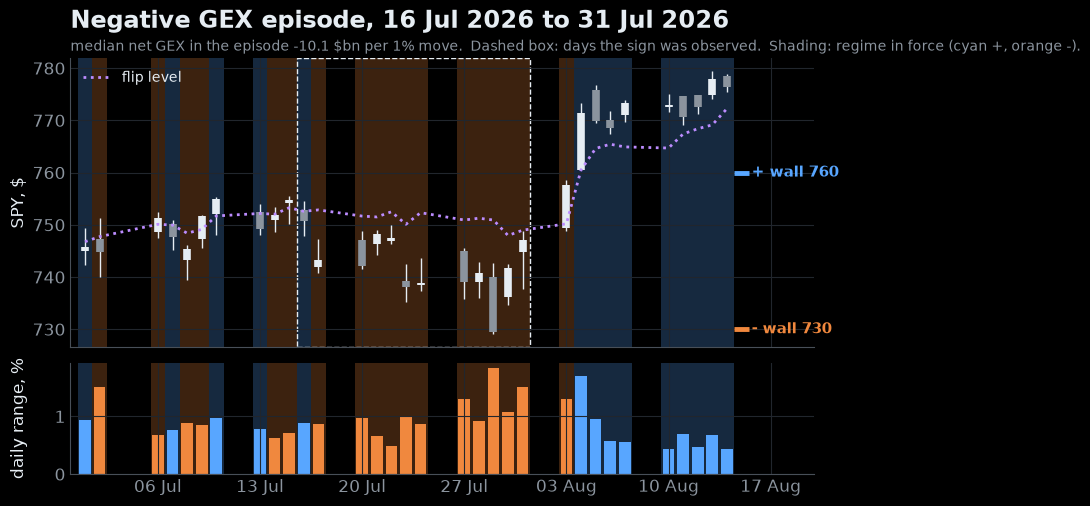

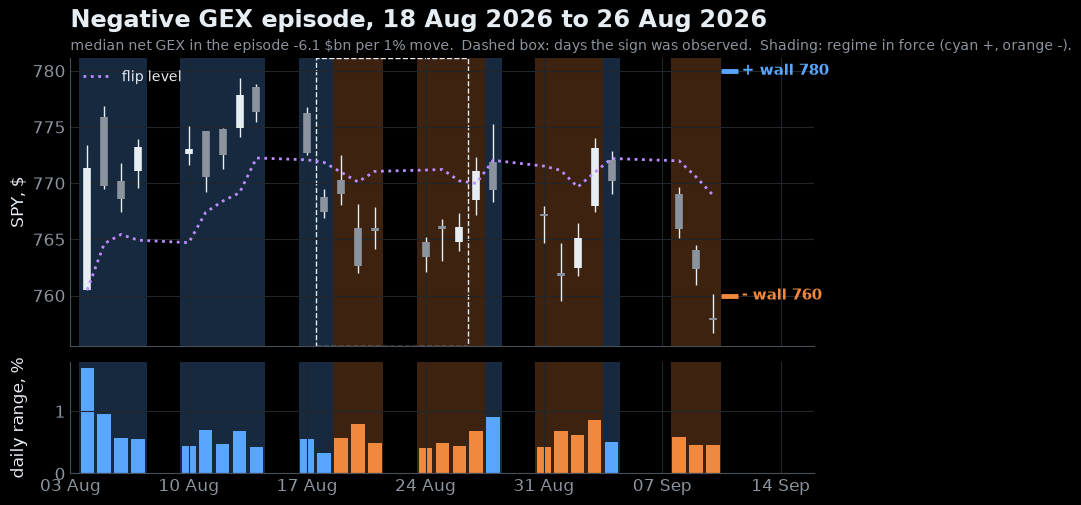

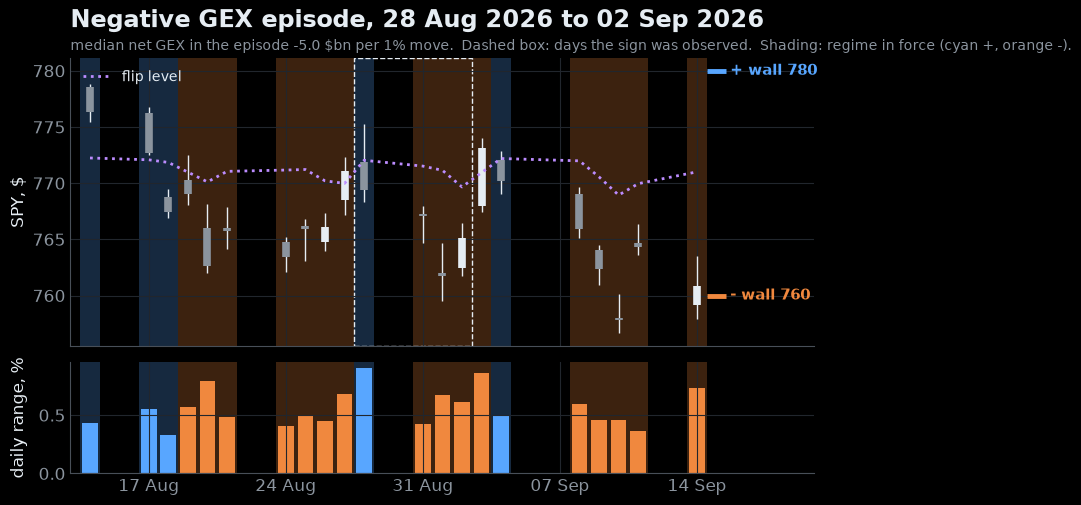

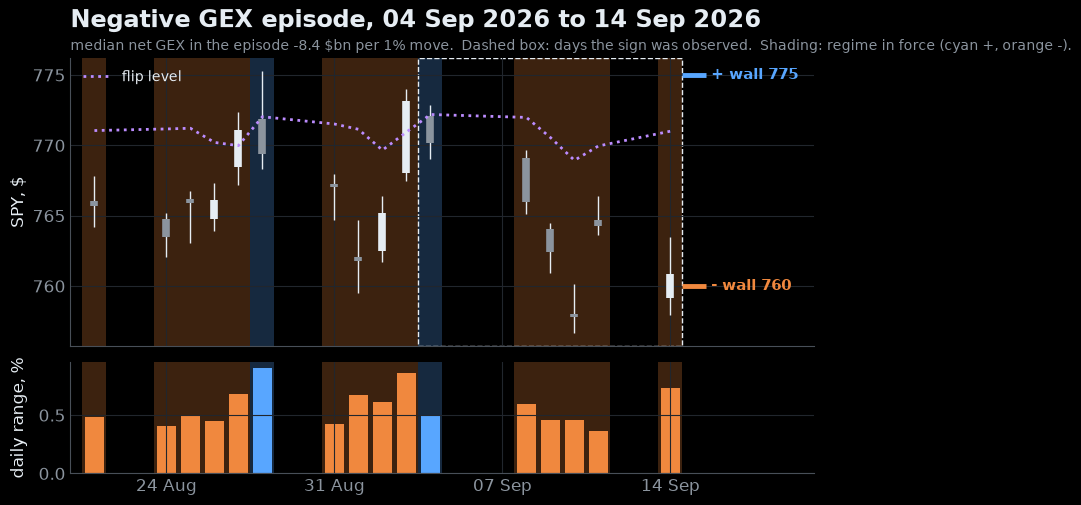

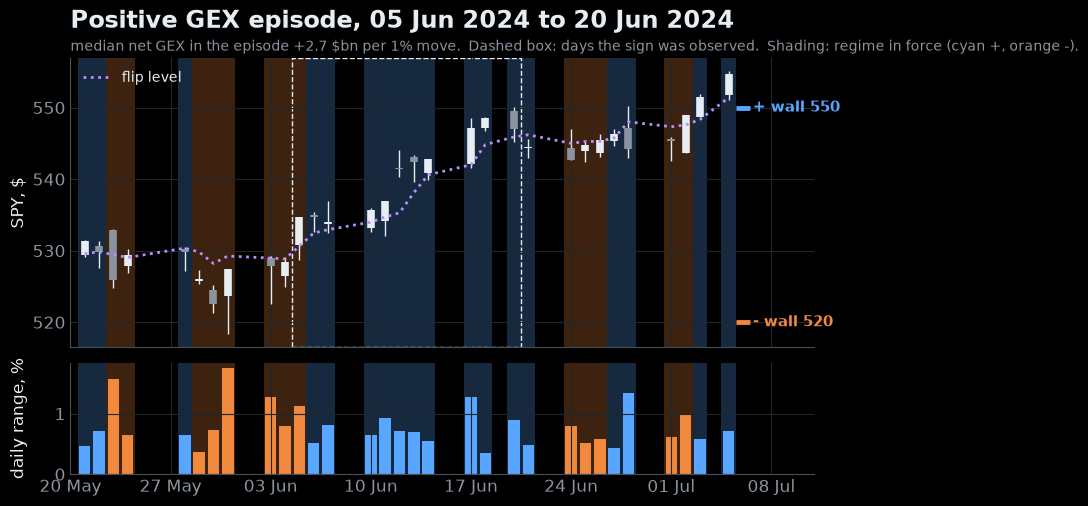

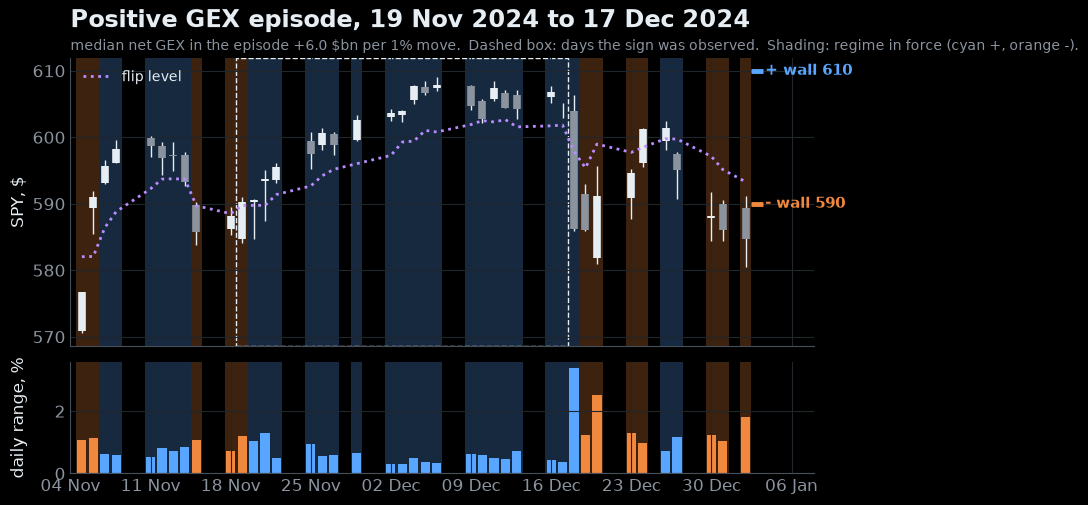

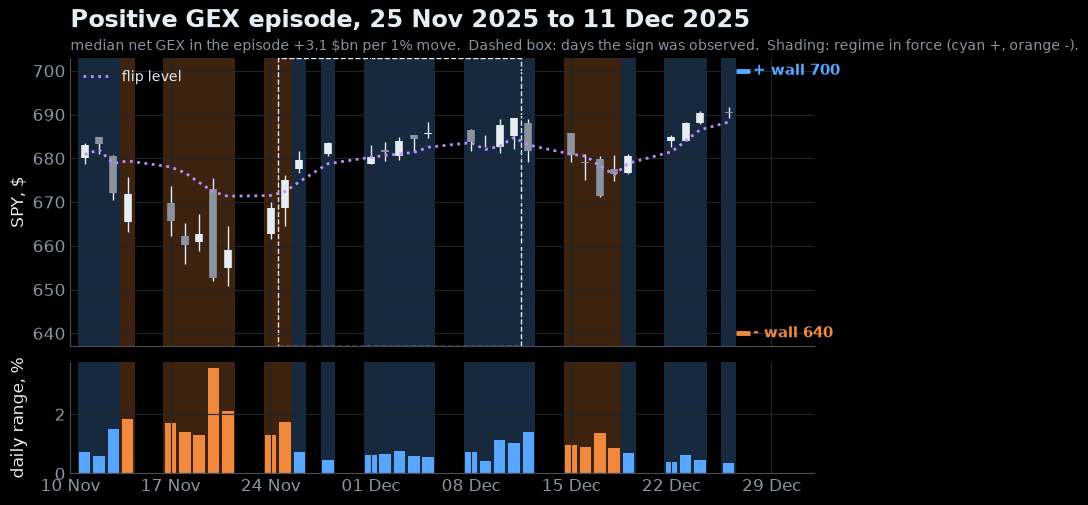

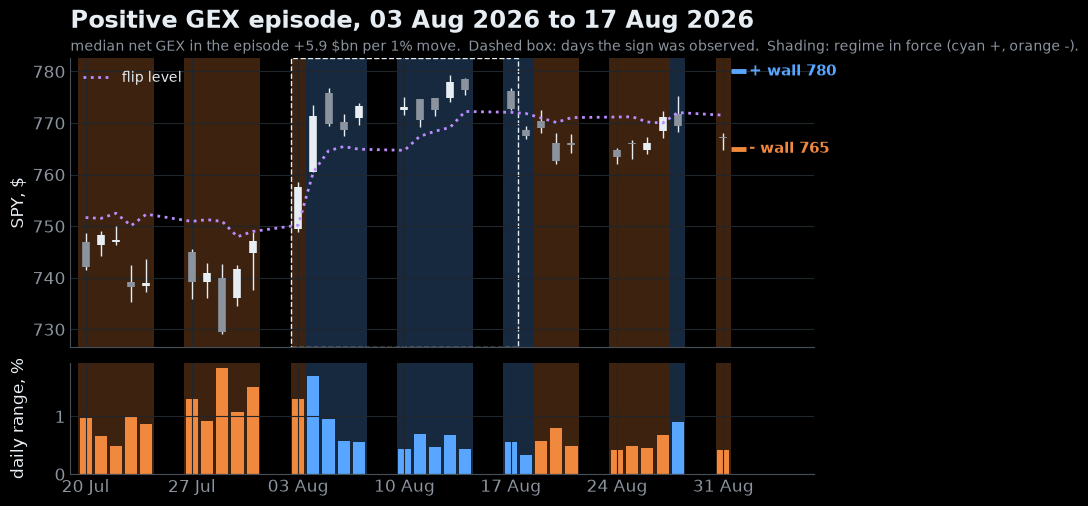

In [10]:
for _, r in eps.iterrows():
    _ = G.fig_episode(daily, stock, r["start"], r["end"], r["kind"], G.FIGURES / f"f2_ep_{r['kind']}_{pd.Timestamp(r['start']):%Y-%m-%d}.png")

## Next-session tests conditioned on the sign

All outcomes are measured on D+1 (or D+1 to D+5) conditioned on the regime known at the close of D. For each test: n per regime, mean and median per regime, the difference (positive minus negative), a bootstrap 95% CI of the difference (10,000 resamples, seed 0) and a two-sided Mann-Whitney U p-value. The autocorrelation row reports the lag-1 correlation of daily returns within each regime, a bootstrap CI of the difference in correlations, and the Mann-Whitney p-value of the per-day products ret(D) x ret(D+1). "Supported" means the difference has the expected sign and the CI excludes zero.

In [11]:
out = G.next_day_outcomes(daily, stock)
tests = G.regime_tests(out, out["regime"])
tests["verdict"] = G.verdicts(tests)
share_min = min((out.regime < 0).mean(), (out.regime > 0).mean())
print(f"sign cut: {int((out.regime > 0).sum())} positive days, {int((out.regime < 0).sum())} negative days")
tfmt = {"mean_pos": "{:.4f}", "mean_neg": "{:.4f}", "median_pos": "{:.4f}", "median_neg": "{:.4f}", "diff": "{:+.4f}", "ci_lo": "{:+.4f}", "ci_hi": "{:+.4f}", "p_mwu": "{:.3f}"}
tests.drop(columns=["outcome"]).style.format(tfmt)

sign cut: 316 positive days, 435 negative days


,n_pos,n_neg,mean_pos,mean_neg,median_pos,median_neg,diff,ci_lo,ci_hi,p_mwu,expectation,verdict
test,,,,,,,,,,,,
range,316,434,0.0075,0.0122,0.0068,0.0106,-0.0047,-0.0057,-0.0039,0.000,lower in +GEX,supported
move,316,434,0.0046,0.0080,0.0035,0.0063,-0.0034,-0.0043,-0.0025,0.000,lower in +GEX,supported
forward vol,316,430,0.0984,0.1474,0.0885,0.1283,-0.0490,-0.0608,-0.0381,0.000,lower in +GEX,supported
continuation,316,434,0.5475,0.4954,1.0000,0.0000,+0.0521,-0.0207,+0.1243,0.159,lower in +GEX,not supported
gap fade,316,434,0.5411,0.4977,1.0000,0.0000,+0.0434,-0.0268,+0.1177,0.240,higher in +GEX,"direction only, CI includes 0"
autocorrelation,316,434,0.0645,-0.0882,nan,nan,+0.1526,-0.0964,+0.3654,0.051,negative in +GEX,not supported


In [12]:
tests_t = None
if share_min < 0.05:
    terc = G.tercile_cut(out)
    tests_t = G.regime_tests(out, terc)
    tests_t["verdict"] = G.verdicts(tests_t)
    print(f"one sign holds fewer than 5% of days, so a second cut on terciles of GEX is added: "
          f"top third ({int((terc == 1).sum())} days) against bottom third ({int((terc == -1).sum())} days)")
    display(tests_t.drop(columns=["outcome"]).style.format(tfmt))
else:
    print(f"both signs hold at least 5% of days (smaller share {share_min:.1%}); the tercile cut is not needed")

both signs hold at least 5% of days (smaller share 42.1%); the tercile cut is not needed


### Lead against coincidence

Negative GEX is partly a consequence of a selloff: puts get bid and spot falls toward the put wall. The leading claim needs the k > 0 side of the cross-correlation between GEX on D and the daily range on D+k to hold up, and the k < 0 side is shown next to it.

corr(GEX on D, range on D+k): k=0 -0.397; mean over k=1..5 -0.322; mean over k=-5..-1 -0.238
negative values mean lower GEX goes with a wider range


k,-5,-4,-3,-2,-1,0,1,2,3,4,5
pearson,-0.181,-0.212,-0.235,-0.252,-0.308,-0.397,-0.388,-0.363,-0.330,-0.284,-0.246
spearman,-0.168,-0.217,-0.268,-0.297,-0.369,-0.513,-0.518,-0.471,-0.403,-0.324,-0.284
n,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,750.000000,749.000000,748.000000,747.000000,746.000000


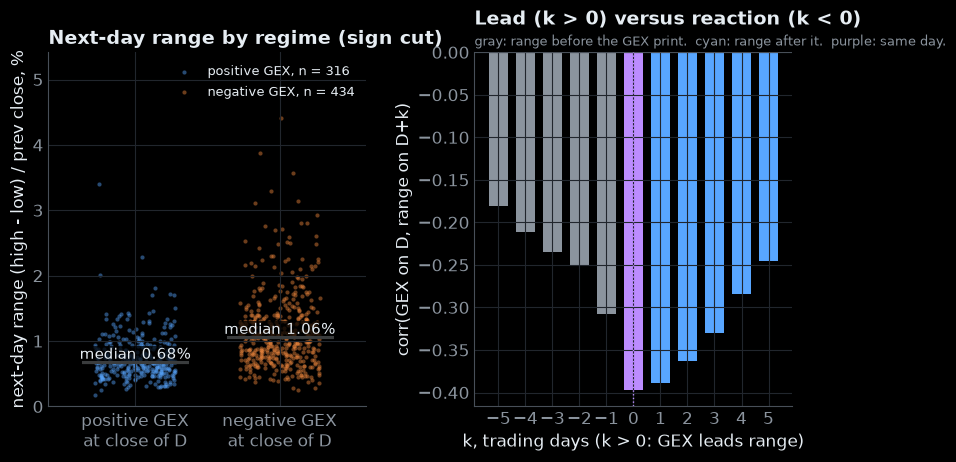

In [13]:
xc = G.cross_correlation(daily, stock)
lead = xc.loc[1:5, "pearson"].mean(); react = xc.loc[-5:-1, "pearson"].mean()
print(f"corr(GEX on D, range on D+k): k=0 {xc.loc[0, 'pearson']:+.3f}; mean over k=1..5 {lead:+.3f}; mean over k=-5..-1 {react:+.3f}")
print("negative values mean lower GEX goes with a wider range")
_ = G.fig_lead_test(out, xc, out["regime"], "sign cut", G.FIGURES / "f3_lead_test.png")
if tests_t is not None:
    _ = G.fig_lead_test(out, xc, terc, "tercile cut", G.FIGURES / "f3b_lead_test_terciles.png")
xc.T.style.format("{:+.3f}", subset=pd.IndexSlice[["pearson", "spearman"], :])

Result: the correlation of net GEX on D with the range on D+1 is -0.39 (Spearman -0.52), with the range on D-1 it is -0.31 (Spearman -0.37), and at k = 0 it is -0.40; the k = 1..5 side averages -0.32 against -0.24 for k = -5..-1. The leading side is the stronger one, but both sides are large because GEX and the daily range are both persistent, so the sign describes the vol regime that is already in place and carries into the next session rather than an independent trigger.

### Pinning

SPY lists expirations every weekday in this window, so every day is an expiration day. Distance from the close of D to the positive wall known at the close of D-1, in percent of S, by the regime in force on D. Baseline: distance to the nearest 5-dollar strike. Third Fridays, where the monthly open interest sits, are shown as a subgroup. A null result stays in the notebook.

In [14]:
pin = G.pinning_test(daily)
pin.style.format("{:.3f}")

## Intraday reversal

30-minute log returns from the SPY 1-minute bars (last 1-minute close per 30-minute bucket, 12 returns per full session). Per day, the lag-1 autocorrelation of those returns; then the mean by the regime in force with a bootstrap 95% CI. Expectation: negative under positive GEX, less negative or positive under negative GEX.

743 days with 30-minute returns; Mann-Whitney p (+ against -): 0.275


,mean,median,ci_lo,ci_hi,n
regime,,,,,
1,-0.093,-0.091,-0.125,-0.060,310
-1,-0.066,-0.081,-0.094,-0.037,433


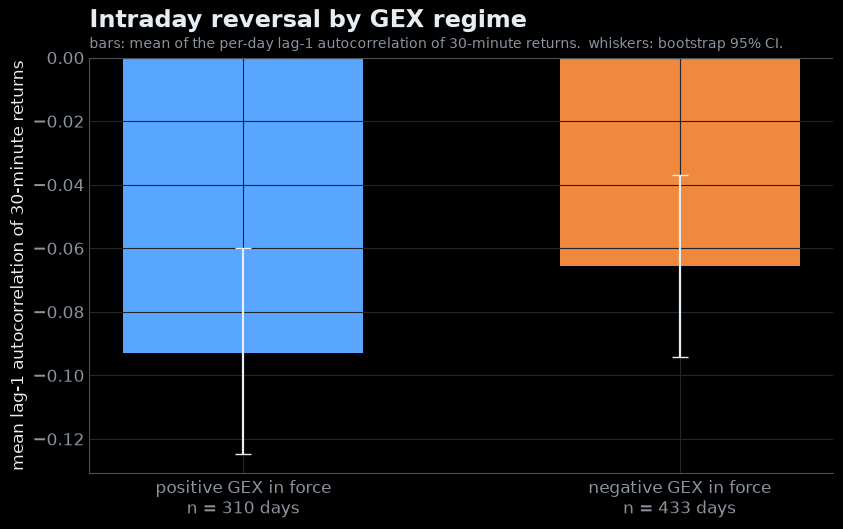

In [15]:
per_day, itab, ip = G.intraday_autocorr(daily)
stats = {"cut": "sign of gex_net_usd at the close of D, in force for D+1", "n_days": int(len(out)),
         "share_negative_days": float((out.regime < 0).mean()), "tests_sign_cut": tests.reset_index().to_dict("records"),
         "tests_tercile_cut": None if tests_t is None else tests_t.reset_index().to_dict("records"),
         "cross_correlation_gex_vs_range": xc.reset_index().to_dict("records"),
         "pinning": pin.reset_index().to_dict("records")}
if itab is None:
    print("no 1-minute cache: step 7 skipped")
else:
    stats["intraday_ac1_by_regime"] = itab.reset_index().to_dict("records"); stats["intraday_mwu_p"] = ip
    print(f"{len(per_day)} days with 30-minute returns; Mann-Whitney p (+ against -): {ip:.3f}")
    display(itab.style.format({"mean": "{:+.3f}", "median": "{:+.3f}", "ci_lo": "{:+.3f}", "ci_hi": "{:+.3f}"}))
    _ = G.fig_intraday(itab, G.FIGURES / "f5_intraday_autocorr.png")
G.save_json(stats, G.RESULTS / "regime_stats.json")

## Vendor gamma cross-check

Theta Data provides Greeks with the EOD report. The series recomputes them for a consistent American model across the whole chain and for refresh rate. Here the vendor gamma replaces the engine gamma with the same rows, open interest and formula. Table: daily correlation of vendor and engine net GEX, sign agreement, median and p99 of the relative difference, the absolute difference in dollars, and the same restricted to contracts within 7 days of expiry. The relative difference of a net figure is large on days when the net is near zero, so the absolute difference is the number to read. The ratio of vendor to engine GEX is given for calls and puts separately, and the second table shows the median relative gamma difference by expiry and moneyness bucket.

{
 "vendor_gamma_missing_share_rows": 0.0,
 "vendor_gamma_missing_share_oi": 0.0,
 "vendor_gamma_zero_share_rows": 0.02324713443754636,
 "daily_vendor_over_engine_gex_by_right": {
  "calls": {
   "median": 1.0062799815826005,
   "p10": 0.995898551652417,
   "p90": 1.0122105845320164
  },
  "puts": {
   "median": 0.9571704211555472,
   "p10": 0.9396505790057325,
   "p90": 0.9675414117340618
  }
 },
 "all": {
  "n_days": 751,
  "corr": 0.9991990630826291,
  "sign_agreement": 0.9454061251664447,
  "rel_diff_median": 0.18052362143009854,
  "rel_diff_p99": 10.062815820075631,
  "abs_diff_usd_median": 717885632.87059,
  "abs_diff_usd_p99": 1513426140.7365055,
  "vendor_minus_engine_usd_median": 717885632.87059
 },
 "dte_le_7": {
  "n_days": 751,
  "corr": 0.9997679766880354,
  "sign_agreement": 0.9826897470039947,
  "rel_diff_median": 0.04055026804941535,
  "rel_diff_p99": 2.738876274942019,
  "abs_diff_usd_median": 78792461.0191431,
  "abs_diff_usd_p99": 268013936.35142756,
  "vendor_minus_

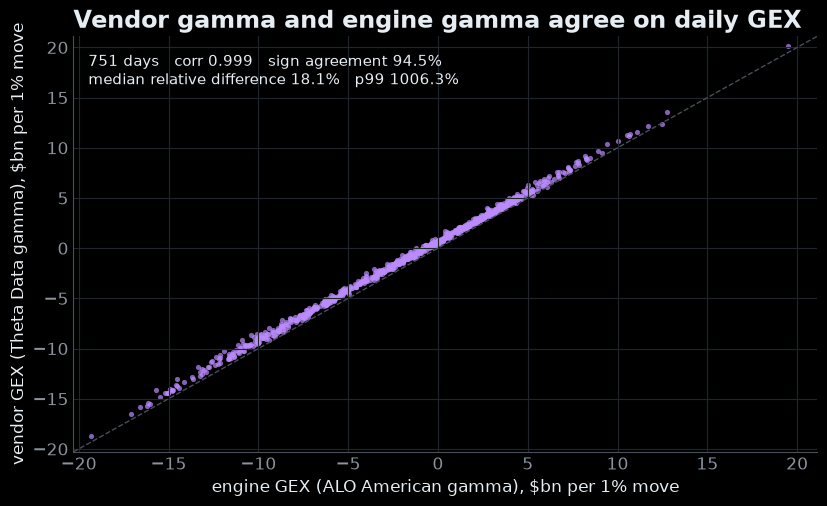

In [16]:
vd, vstats, vtab = G.vendor_compare(sol)
G.save_json(vstats, G.RESULTS / "vendor_vs_engine.json")
print(json.dumps(vstats, indent=1))
_ = G.fig_vendor(vd, vstats, G.FIGURES / "f4_vendor_vs_engine.png")
vtab.style.format("{:+.3f}")

## Conclusions

1. Moves are damped after positive GEX: mean next-day range 0.75% after a positive-GEX close against 1.22% after a negative one, difference -0.47%, 95% CI [-0.57%, -0.39%], p < 0.001 (supported); mean absolute next-day return 0.46% after a positive-GEX close against 0.80% after a negative one, difference -0.34%, 95% CI [-0.43%, -0.25%], p < 0.001 (supported).
2. Realized vol is lower after positive GEX: mean annualized 5-day forward vol 9.8% after a positive-GEX close against 14.7% after a negative one, difference -4.9%, 95% CI [-6.1%, -3.8%], p < 0.001 (supported).
3. Trends do not extend more under negative GEX: the next-day continuation rate is 54.7% after a positive-GEX close against 49.5% after a negative one, difference 5.2%, 95% CI [-2.1%, 12.4%], p = 0.159, the reverse of the claim (not supported), and the lag-1 autocorrelation of daily returns is +0.064 under positive GEX against -0.088 under negative, again the reverse (not supported).
4. Gaps fade slightly more often after positive GEX: 54.1% after a positive-GEX close against 49.8% after a negative one, difference 4.3%, 95% CI [-2.7%, 11.8%], p = 0.240 (direction only, CI includes 0).
5. Pinning is proximity, not attraction: the close sits 0.79% from the positive wall under positive GEX against 2.89% under negative, but the close moved toward the wall on 44.6% of positive-GEX days against 54.6% of negative-GEX days (not supported).
6. Intraday reversal is in the expected order but not distinguishable: mean lag-1 autocorrelation of 30-minute returns -0.093 under positive GEX (95% CI [-0.125, -0.060], n = 310) against -0.066 under negative ([-0.094, -0.037], n = 433), Mann-Whitney p = 0.275 (direction only, CI overlap).

Net GEX was negative on 58% of the 751 days, so the positive-GEX sample is the smaller one. Result: the correlation of net GEX on D with the range on D+1 is -0.39 (Spearman -0.52), with the range on D-1 it is -0.31 (Spearman -0.37), and at k = 0 it is -0.40; the k = 1..5 side averages -0.32 against -0.24 for k = -5..-1. The leading side is the stronger one, but both sides are large because GEX and the daily range are both persistent, so the sign describes the vol regime that is already in place and carries into the next session rather than an independent trigger.

Educational analysis, not a trading strategy.